In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from datetime import datetime
from scipy.stats import chi2_contingency
from scipy.stats import kruskal
from scipy.stats import mannwhitneyu

In [3]:
df = pd.read_excel('data/working_dataset.xlsx')

# Analyse Bivarié

## Variables Qualitatives

### DEFAUT x INDLIB_GROUPE

In [3]:
variable = 'INDLIB_GROUPE'
target = 'DEFAUT'

In [4]:
# Table des effectifs
table_count = pd.crosstab(df[variable], df[target])

# Table des pourcentages par ligne
table_pct = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100).round(2)

# Combiner effectifs et pourcentages
table_finale = (
    table_count.astype(str)
    + " ("
    + table_pct.astype(str)
    + "%)"
)

table_finale

DEFAUT,0,1
INDLIB_GROUPE,,
Agriculture/Élevage,7781 (62.93%),4583 (37.07%)
Autres,1446 (82.87%),299 (17.13%)
BTP/Construction,248 (48.44%),264 (51.56%)
Commerce,1948 (23.61%),6301 (76.39%)
Industrie,389 (52.28%),355 (47.72%)
Services,640 (30.81%),1437 (69.19%)
Transport,58 (36.94%),99 (63.06%)


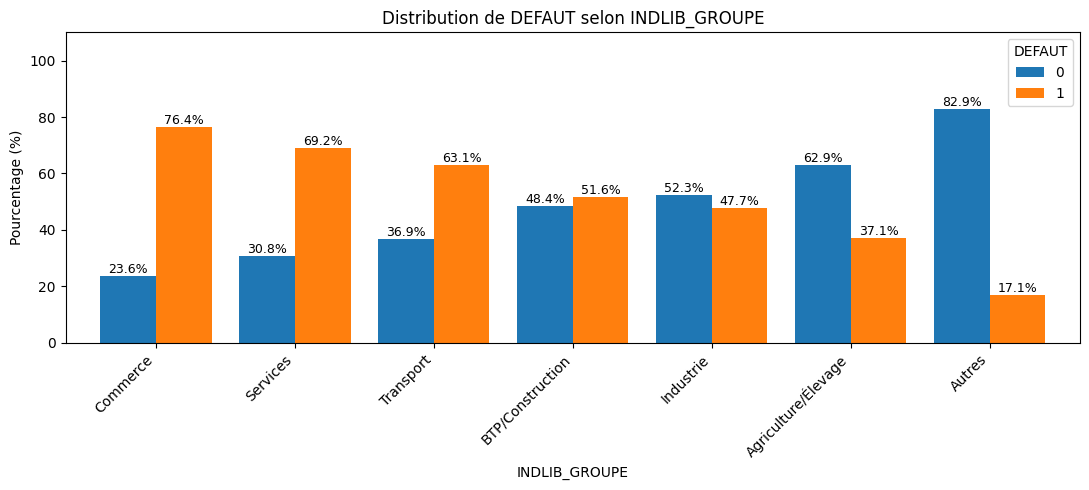

In [5]:
# Préparer les pourcentages
table_pct_graph = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100)

# Trier selon le taux de défaut = 1
table_pct_graph = table_pct_graph.sort_values(by=1, ascending=False)

# Graphique
ax = table_pct_graph.plot(
    kind='bar',
    figsize=(11, 5),
    width=0.8
)

# Ajouter les pourcentages sur les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        fontsize=9
    )

plt.xlabel(variable)
plt.ylabel('Pourcentage (%)')
plt.title(f'Distribution de {target} selon {variable}')
plt.xticks(rotation=45, ha='right')
plt.legend(title=target)
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

In [7]:
chi2, p_value, dof, expected = chi2_contingency(table_count)

print("Statistique Chi-square :", round(chi2, 4))
print("p-value :", p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print(f"Conclusion : Il existe une relation significative entre {variable} et {target}.")
else:
    print(f"Conclusion : Il n'existe pas de relation significative entre {variable} et {target}.")

Statistique Chi-square : 4174.537
p-value : 0.0
Degrés de liberté : 6
Conclusion : Il existe une relation significative entre INDLIB_GROUPE et DEFAUT.


In [8]:
n = table_count.sum().sum()
r, k = table_count.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("Cramér's V :", round(cramers_v, 4))

if cramers_v < 0.1:
    interpretation = "très faible"
elif cramers_v < 0.3:
    interpretation = "faible"
elif cramers_v < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La force de la relation est {interpretation}.")

Cramér's V : 0.4019
Interprétation : La force de la relation est modérée.


### DEFAUT x PORTEF

In [9]:
variable = 'PORTEF'
target = 'DEFAUT'

In [10]:
# Table des effectifs
table_count = pd.crosstab(df[variable], df[target])

# Table des pourcentages par ligne
table_pct = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100).round(2)

# Tableau final : effectif (pourcentage)
table_finale = (
    table_count.astype(str)
    + " ("
    + table_pct.astype(str)
    + "%)"
)

table_finale

DEFAUT,0,1
PORTEF,,
CAM,6756 (91.84%),600 (8.16%)
DD,50 (58.82%),35 (41.18%)
DDC,1605 (89.77%),183 (10.23%)
FSE,2941 (43.41%),3834 (56.59%)
PP,980 (11.24%),7741 (88.76%)
PROJ_M_AV,62 (11.74%),466 (88.26%)
PROPEP,116 (19.5%),479 (80.5%)


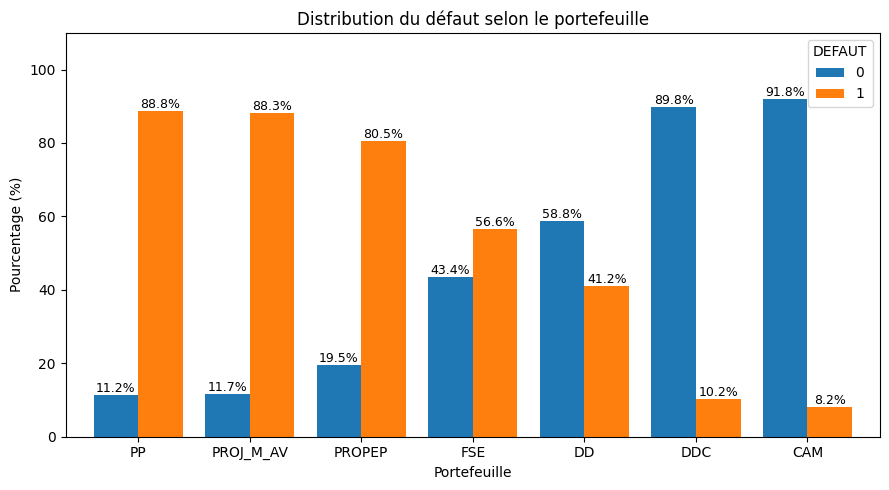

In [11]:
# Préparer les pourcentages
table_pct_graph = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100)

# Trier selon le taux de défaut = 1
table_pct_graph = table_pct_graph.sort_values(by=1, ascending=False)

# Graphique
ax = table_pct_graph.plot(
    kind='bar',
    figsize=(9, 5),
    width=0.8
)

# Ajouter les pourcentages sur les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        fontsize=9
    )

plt.xlabel('Portefeuille')
plt.ylabel('Pourcentage (%)')
plt.title('Distribution du défaut selon le portefeuille')
plt.xticks(rotation=0)
plt.legend(title='DEFAUT')
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

In [14]:
chi2, p_value, dof, expected = chi2_contingency(table_count)

print("Statistique Chi-square :", round(chi2, 4))
print("p-value :", p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print("Conclusion : Il existe une relation significative entre PORTEF et DEFAUT.")
else:
    print("Conclusion : Il n'existe pas de relation significative entre PORTEF et DEFAUT.")

Statistique Chi-square : 12161.0667
p-value : 0.0
Degrés de liberté : 6
Conclusion : Il existe une relation significative entre PORTEF et DEFAUT.


In [15]:
n = table_count.sum().sum()
r, k = table_count.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("Cramér's V :", round(cramers_v, 4))

if cramers_v < 0.1:
    interpretation = "très faible"
elif cramers_v < 0.3:
    interpretation = "faible"
elif cramers_v < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La force de la relation est {interpretation}.")

Cramér's V : 0.6859
Interprétation : La force de la relation est forte.


### DEFAUT x PERIODE

In [16]:
variable = 'PERIODE'
target = 'DEFAUT'

In [17]:
# Table des effectifs
table_count = pd.crosstab(df[variable], df[target])

# Table des pourcentages par ligne
table_pct = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100).round(2)

# Tableau final : effectif (pourcentage)
table_finale = (
    table_count.astype(str)
    + " ("
    + table_pct.astype(str)
    + "%)"
)

table_finale

DEFAUT,0,1
PERIODE,,
M,5873 (31.52%),12762 (68.48%)
S,6578 (93.27%),475 (6.73%)
T,59 (36.88%),101 (63.12%)


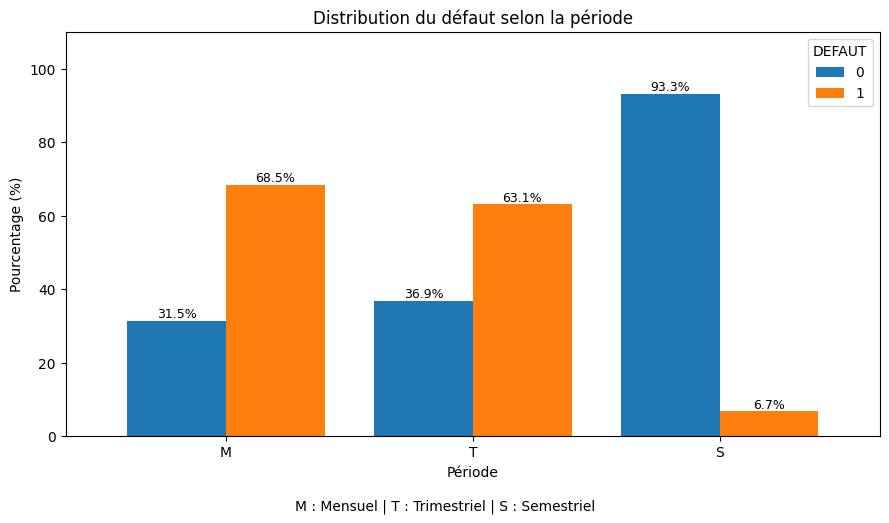

In [20]:
# Préparer les pourcentages
table_pct_graph = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100)

# Trier selon le taux de défaut = 1
table_pct_graph = table_pct_graph.sort_values(by=1, ascending=False)

# Graphique
ax = table_pct_graph.plot(
    kind='bar',
    figsize=(9, 5),
    width=0.8
)

# Ajouter les pourcentages sur les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        fontsize=9
    )

plt.xlabel('Période')
plt.ylabel('Pourcentage (%)')
plt.title('Distribution du défaut selon la période')
plt.xticks(rotation=0)
plt.legend(title='DEFAUT')
plt.ylim(0, 110)

plt.figtext(
    0.5, -0.03,
    "M : Mensuel | T : Trimestriel | S : Semestriel",
    ha='center',
    fontsize=10
)

plt.tight_layout()
plt.show()

In [21]:
chi2, p_value, dof, expected = chi2_contingency(table_count)

print("Statistique Chi-square :", round(chi2, 4))
print("p-value :", p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print("Conclusion : Il existe une relation significative entre PERIODE et DEFAUT.")
else:
    print("Conclusion : Il n'existe pas de relation significative entre PERIODE et DEFAUT.")

Statistique Chi-square : 7820.2161
p-value : 0.0
Degrés de liberté : 2
Conclusion : Il existe une relation significative entre PERIODE et DEFAUT.


In [22]:
n = table_count.sum().sum()
r, k = table_count.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("Cramér's V :", round(cramers_v, 4))

if cramers_v < 0.1:
    interpretation = "très faible"
elif cramers_v < 0.3:
    interpretation = "faible"
elif cramers_v < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La force de la relation est {interpretation}.")

Cramér's V : 0.55
Interprétation : La force de la relation est forte.


### DEFAUT x SEX

In [23]:
variable = 'SEX'
target = 'DEFAUT'

In [24]:
# Table des effectifs
table_count = pd.crosstab(df[variable], df[target])

# Table des pourcentages par ligne
table_pct = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100).round(2)

# Tableau final : effectif (pourcentage)
table_finale = (
    table_count.astype(str)
    + " ("
    + table_pct.astype(str)
    + "%)"
)

table_finale

DEFAUT,0,1
SEX,,
Female,2925 (31.14%),6469 (68.86%)
Male,9585 (58.25%),6869 (41.75%)


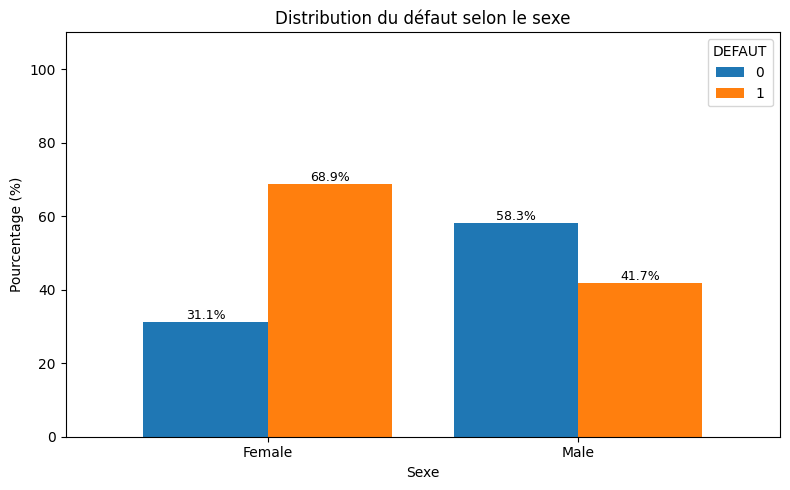

In [25]:
# Préparer les pourcentages
table_pct_graph = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100)

# Trier selon le taux de défaut = 1
table_pct_graph = table_pct_graph.sort_values(by=1, ascending=False)

# Graphique
ax = table_pct_graph.plot(
    kind='bar',
    figsize=(8, 5),
    width=0.8
)

# Ajouter les pourcentages sur les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        fontsize=9
    )

plt.xlabel('Sexe')
plt.ylabel('Pourcentage (%)')
plt.title('Distribution du défaut selon le sexe')
plt.xticks(rotation=0)
plt.legend(title='DEFAUT')
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

In [28]:
chi2, p_value, dof, expected = chi2_contingency(table_count)

print("Statistique Chi-square :", round(chi2, 4))
print("p-value :", p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print("Conclusion : Il existe une relation significative entre SEX et DEFAUT.")
else:
    print("Conclusion : Il n'existe pas de relation significative entre SEX et DEFAUT.")

Statistique Chi-square : 1759.5341
p-value : 0.0
Degrés de liberté : 1
Conclusion : Il existe une relation significative entre SEX et DEFAUT.


In [29]:
n = table_count.sum().sum()
r, k = table_count.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("Cramér's V :", round(cramers_v, 4))

if cramers_v < 0.1:
    interpretation = "très faible"
elif cramers_v < 0.3:
    interpretation = "faible"
elif cramers_v < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La force de la relation est {interpretation}.")

Cramér's V : 0.2609
Interprétation : La force de la relation est faible.


### DEFAUT x AGENCE_LIEU

In [30]:
variable = 'AGENCE_LIEU'
target = 'DEFAUT'

In [31]:
# Table des effectifs
table_count = pd.crosstab(df[variable], df[target])

# Table des pourcentages par ligne
table_pct = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100).round(2)

# Tableau final : effectif (pourcentage)
table_finale = (
    table_count.astype(str)
    + " ("
    + table_pct.astype(str)
    + "%)"
)

table_finale

DEFAUT,0,1
AGENCE_LIEU,,
Adrar,471 (40.39%),695 (59.61%)
Assaba,204 (13.34%),1325 (86.66%)
Brakna,957 (33.48%),1901 (66.52%)
Dakhlet Nouadhibou,611 (59.49%),416 (40.51%)
Gorgol,1580 (47.5%),1746 (52.5%)
Guidimagha,139 (11.49%),1071 (88.51%)
Hodh Chargui,265 (14.85%),1519 (85.15%)
Hodh Gharbi,211 (15.9%),1116 (84.1%)
Inchiri,131 (17.82%),604 (82.18%)


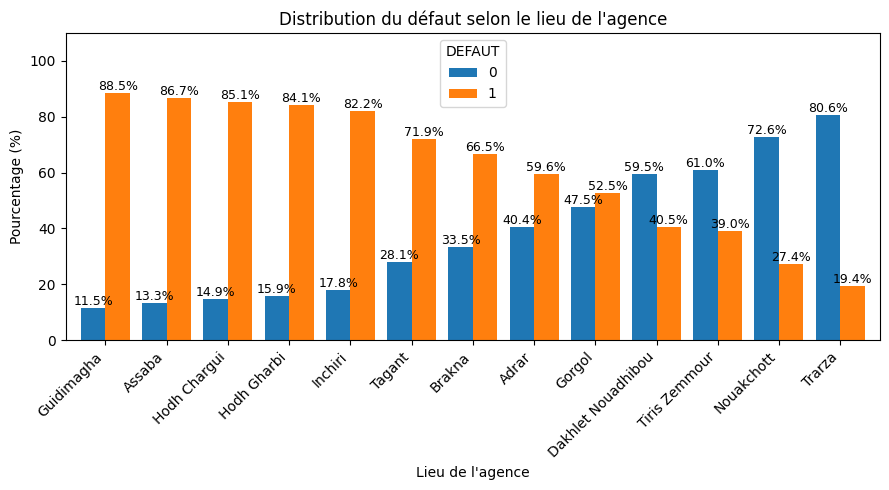

In [32]:
# Préparer les pourcentages
table_pct_graph = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100)

# Trier selon le taux de défaut = 1
table_pct_graph = table_pct_graph.sort_values(by=1, ascending=False)

# Graphique
ax = table_pct_graph.plot(
    kind='bar',
    figsize=(9, 5),
    width=0.8
)

# Ajouter les pourcentages sur les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        fontsize=9
    )

plt.xlabel("Lieu de l'agence")
plt.ylabel('Pourcentage (%)')
plt.title("Distribution du défaut selon le lieu de l'agence")
plt.xticks(rotation=45, ha='right')
plt.legend(title='DEFAUT')
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

In [33]:
chi2, p_value, dof, expected = chi2_contingency(table_count)

print("Statistique Chi-square :", round(chi2, 4))
print("p-value :", p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print("Conclusion : Il existe une relation significative entre AGENCE_LIEU et DEFAUT.")
else:
    print("Conclusion : Il n'existe pas de relation significative entre AGENCE_LIEU et DEFAUT.")

Statistique Chi-square : 6969.6235
p-value : 0.0
Degrés de liberté : 12
Conclusion : Il existe une relation significative entre AGENCE_LIEU et DEFAUT.


In [34]:
n = table_count.sum().sum()
r, k = table_count.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("Cramér's V :", round(cramers_v, 4))

if cramers_v < 0.1:
    interpretation = "très faible"
elif cramers_v < 0.3:
    interpretation = "faible"
elif cramers_v < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La force de la relation est {interpretation}.")

Cramér's V : 0.5193
Interprétation : La force de la relation est forte.


### DEFAUT x ETATCIVIL

In [35]:
variable = 'ETATCIVIL'
target = 'DEFAUT'

In [36]:
# Table des effectifs
table_count = pd.crosstab(df[variable], df[target])

# Table des pourcentages par ligne
table_pct = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100).round(2)

# Tableau final : effectif (pourcentage)
table_finale = (
    table_count.astype(str)
    + " ("
    + table_pct.astype(str)
    + "%)"
)

table_finale

DEFAUT,0,1
ETATCIVIL,,
Divorced,241 (25.53%),703 (74.47%)
Married,10486 (53.27%),9199 (46.73%)
Single,1783 (34.16%),3436 (65.84%)


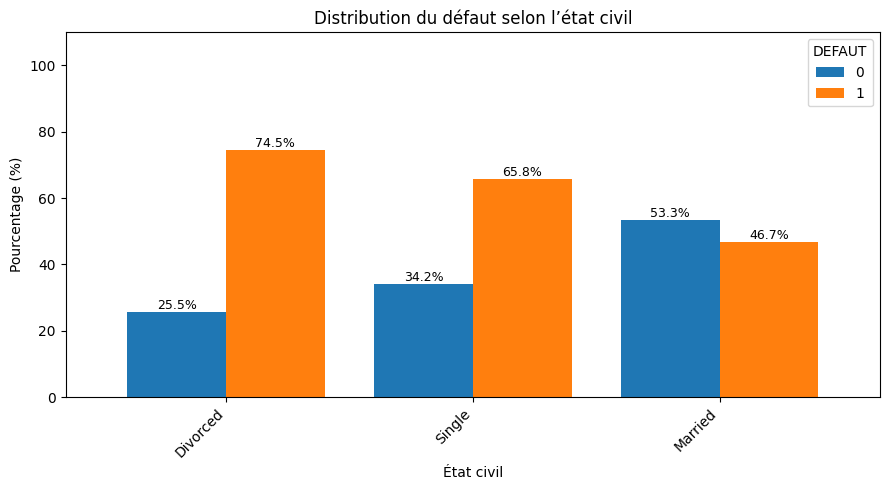

In [37]:
# Préparer les pourcentages
table_pct_graph = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100)

# Trier selon le taux de défaut = 1
table_pct_graph = table_pct_graph.sort_values(by=1, ascending=False)

# Graphique
ax = table_pct_graph.plot(
    kind='bar',
    figsize=(9, 5),
    width=0.8
)

# Ajouter les pourcentages sur les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        fontsize=9
    )

plt.xlabel("État civil")
plt.ylabel("Pourcentage (%)")
plt.title("Distribution du défaut selon l’état civil")
plt.xticks(rotation=45, ha='right')
plt.legend(title='DEFAUT')
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

In [39]:
chi2, p_value, dof, expected = chi2_contingency(table_count)

print("Statistique Chi-square :", round(chi2, 4))
print("p-value :", p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print("Conclusion : Il existe une relation significative entre ETATCIVIL et DEFAUT.")
else:
    print("Conclusion : Il n'existe pas de relation significative entre ETATCIVIL et DEFAUT.")

Statistique Chi-square : 808.1055
p-value : 3.327524454192334e-176
Degrés de liberté : 2
Conclusion : Il existe une relation significative entre ETATCIVIL et DEFAUT.


In [40]:
n = table_count.sum().sum()
r, k = table_count.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("Cramér's V :", round(cramers_v, 4))

if cramers_v < 0.1:
    interpretation = "très faible"
elif cramers_v < 0.3:
    interpretation = "faible"
elif cramers_v < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La force de la relation est {interpretation}.")

Cramér's V : 0.1768
Interprétation : La force de la relation est faible.


### DEFAUT x WILAYA_NAISSANCE

In [41]:
variable = 'WILAYA_NAISSANCE'
target = 'DEFAUT'

In [42]:
# Table des effectifs
table_count = pd.crosstab(df[variable], df[target])

# Table des pourcentages par ligne
table_pct = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100).round(2)

# Tableau final : effectif (pourcentage)
table_finale = (
    table_count.astype(str)
    + " ("
    + table_pct.astype(str)
    + "%)"
)

table_finale

DEFAUT,0,1
WILAYA_NAISSANCE,,
Adrar,850 (55.09%),693 (44.91%)
Assaba,508 (27.02%),1372 (72.98%)
Brakna,1336 (42.89%),1779 (57.11%)
Gorgol,1606 (50.5%),1574 (49.5%)
Guidimakha,272 (20.7%),1042 (79.3%)
Hodh Ech Chargui,372 (19.85%),1502 (80.15%)
Hodh el Gharbi,400 (64.62%),219 (35.38%)
Inchiri,185 (22.59%),634 (77.41%)
Inconnu,2421 (58.58%),1712 (41.42%)


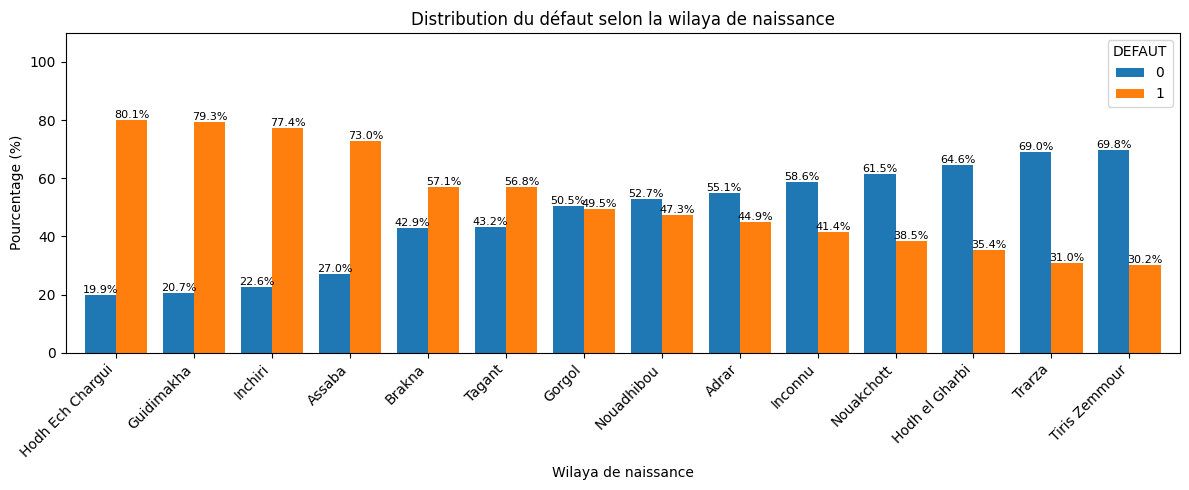

In [43]:
# Préparer les pourcentages
table_pct_graph = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100)

# Trier selon le taux de défaut = 1
table_pct_graph = table_pct_graph.sort_values(by=1, ascending=False)

# Graphique
ax = table_pct_graph.plot(
    kind='bar',
    figsize=(12, 5),
    width=0.8
)

# Ajouter les pourcentages sur les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        fontsize=8
    )

plt.xlabel("Wilaya de naissance")
plt.ylabel("Pourcentage (%)")
plt.title("Distribution du défaut selon la wilaya de naissance")
plt.xticks(rotation=45, ha='right')
plt.legend(title='DEFAUT')
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

In [44]:
chi2, p_value, dof, expected = chi2_contingency(table_count)

print("Statistique Chi-square :", round(chi2, 4))
print("p-value :",p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print("Conclusion : Il existe une relation significative entre WILAYA_NAISSANCE et DEFAUT.")
else:
    print("Conclusion : Il n'existe pas de relation significative entre WILAYA_NAISSANCE et DEFAUT.")

Statistique Chi-square : 2701.0157
p-value : 0.0
Degrés de liberté : 13
Conclusion : Il existe une relation significative entre WILAYA_NAISSANCE et DEFAUT.


In [45]:
n = table_count.sum().sum()
r, k = table_count.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("Cramér's V :", round(cramers_v, 4))

if cramers_v < 0.1:
    interpretation = "très faible"
elif cramers_v < 0.3:
    interpretation = "faible"
elif cramers_v < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La force de la relation est {interpretation}.")

Cramér's V : 0.3233
Interprétation : La force de la relation est modérée.


In [46]:
df.duplicated().sum()

np.int64(172)

## Variables Quantitatives

### DEFAUT x MONTANT

In [4]:
variable = 'MONTANT'
target = 'DEFAUT'

# Convertir MONTANT en numérique
df[variable] = pd.to_numeric(df[variable], errors='coerce')

# Garder seulement les lignes utiles
data = df[[variable, target]].dropna()

# Garder seulement DEFAUT = 0 et DEFAUT = 1
data = data[data[target].isin([0, 1])]

In [6]:
summary_montant = data.groupby(target)[variable].agg(
    Effectif='count',
    Moyenne='mean',
    Médiane='median',
    Minimum='min',
    Maximum='max',
    Ecart_type='std'
).round(2)

summary_montant

,Effectif,Moyenne,Médiane,Minimum,Maximum,Ecart_type
DEFAUT,,,,,,
0,12431,170496.90,59260.0,10000.0,83010000.0,1088676.40
1,13249,102749.64,20000.0,10000.0,41018069.0,937287.77


<Figure size 800x500 with 0 Axes>

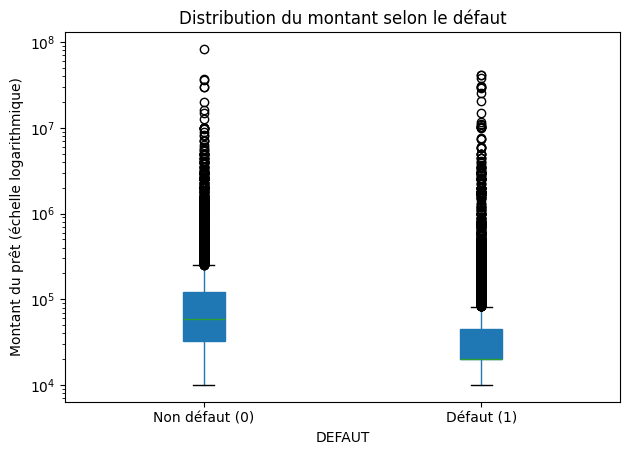

In [7]:
plt.figure(figsize=(8, 5))

data.boxplot(
    column=variable,
    by=target,
    grid=False,
    patch_artist=True
)

plt.yscale('log')

plt.title('Distribution du montant selon le défaut')
plt.suptitle('')
plt.xlabel('DEFAUT')
plt.ylabel('Montant du prêt (échelle logarithmique)')
plt.xticks([1, 2], ['Non défaut (0)', 'Défaut (1)'])

plt.tight_layout()
plt.show()

In [10]:
groupe_0 = data.loc[data[target] == 0, variable]
groupe_1 = data.loc[data[target] == 1, variable]

stat, p_value = mannwhitneyu(
    groupe_0,
    groupe_1,
    alternative='two-sided'
)

print("Statistique Mann-Whitney U :", round(stat, 4))
print("p-value :", p_value)

if p_value < 0.05:
    print("Conclusion : Il existe une différence significative du montant entre les clients en défaut et les clients non en défaut.")
else:
    print("Conclusion : Il n'existe pas de différence significative du montant entre les clients en défaut et les clients non en défaut.")

Statistique Mann-Whitney U : 121645568.0
p-value : 0.0
Conclusion : Il existe une différence significative du montant entre les clients en défaut et les clients non en défaut.


In [11]:
n0 = len(groupe_0)
n1 = len(groupe_1)

rank_biserial = (2 * stat) / (n0 * n1) - 1

print("Rank-biserial correlation :", round(rank_biserial, 4))

abs_effect = abs(rank_biserial)

if abs_effect < 0.1:
    interpretation = "très faible"
elif abs_effect < 0.3:
    interpretation = "faible"
elif abs_effect < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La taille de l'effet est {interpretation}.")

Rank-biserial correlation : 0.4772
Interprétation : La taille de l'effet est modérée.


### DEFAUT x DUREE

In [13]:
variable = 'DUREE'
target = 'DEFAUT'

# Convertir DUREE en numérique
df[variable] = pd.to_numeric(df[variable], errors='coerce')

# Garder seulement les lignes utiles
data = df[[variable, target]].dropna()

# Garder seulement DEFAUT = 0 et DEFAUT = 1
data = data[data[target].isin([0, 1])]

In [14]:
summary_duree = data.groupby(target)[variable].agg(
    Effectif='count',
    Moyenne='mean',
    Médiane='median',
    Minimum='min',
    Maximum='max',
    Ecart_type='std'
).round(2)

summary_duree

,Effectif,Moyenne,Médiane,Minimum,Maximum,Ecart_type
DEFAUT,,,,,,
0,12431,18.17,6.0,1,96,14.79
1,13249,34.68,36.0,1,96,7.18


<Figure size 800x500 with 0 Axes>

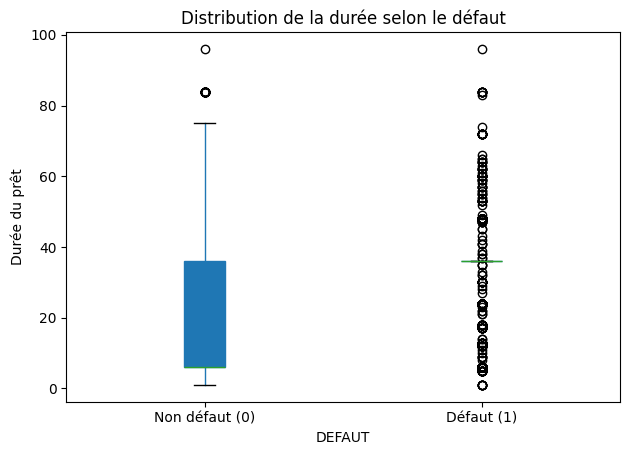

In [15]:
plt.figure(figsize=(8, 5))

data.boxplot(
    column=variable,
    by=target,
    grid=False,
    patch_artist=True
)

plt.title('Distribution de la durée selon le défaut')
plt.suptitle('')
plt.xlabel('DEFAUT')
plt.ylabel('Durée du prêt')
plt.xticks([1, 2], ['Non défaut (0)', 'Défaut (1)'])

plt.tight_layout()
plt.show()

In [16]:
groupe_0 = data.loc[data[target] == 0, variable]
groupe_1 = data.loc[data[target] == 1, variable]

stat, p_value = mannwhitneyu(
    groupe_0,
    groupe_1,
    alternative='two-sided'
)

print("Statistique Mann-Whitney U :", round(stat, 4))
print("p-value :", round(p_value, 4))

if p_value < 0.05:
    print("Conclusion : Il existe une différence significative de la durée entre les clients en défaut et les clients non en défaut.")
else:
    print("Conclusion : Il n'existe pas de différence significative de la durée entre les clients en défaut et les clients non en défaut.")

Statistique Mann-Whitney U : 33961358.0
p-value : 0.0
Conclusion : Il existe une différence significative de la durée entre les clients en défaut et les clients non en défaut.


In [17]:
n0 = len(groupe_0)
n1 = len(groupe_1)

rank_biserial = (2 * stat) / (n0 * n1) - 1

print("Rank-biserial correlation :", round(rank_biserial, 4))

abs_effect = abs(rank_biserial)

if abs_effect < 0.1:
    interpretation = "très faible"
elif abs_effect < 0.3:
    interpretation = "faible"
elif abs_effect < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La taille de l'effet est {interpretation}.")

Rank-biserial correlation : -0.5876
Interprétation : La taille de l'effet est forte.


### DEFAUT x TAUX_INT

In [18]:
variable = 'TAUX_INT'
target = 'DEFAUT'

# Convertir TAUX_INT en numérique
df[variable] = pd.to_numeric(df[variable], errors='coerce')

# Garder seulement les lignes utiles
data = df[[variable, target]].dropna()

# Garder seulement DEFAUT = 0 et DEFAUT = 1
data = data[data[target].isin([0, 1])]

In [19]:
summary_taux_int = data.groupby(target)[variable].agg(
    Effectif='count',
    Moyenne='mean',
    Médiane='median',
    Minimum='min',
    Maximum='max',
    Ecart_type='std'
).round(2)

summary_taux_int

,Effectif,Moyenne,Médiane,Minimum,Maximum,Ecart_type
DEFAUT,,,,,,
0,12431,6.85,6.0,0.0,12.0,4.02
1,13249,4.03,3.0,0.0,12.0,2.20


<Figure size 800x500 with 0 Axes>

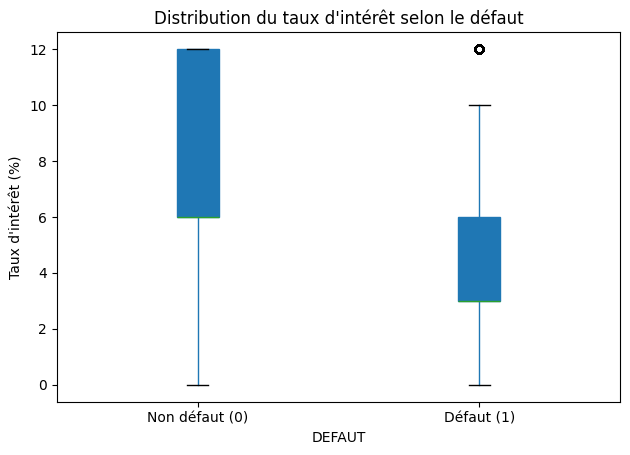

In [20]:
plt.figure(figsize=(8, 5))

data.boxplot(
    column=variable,
    by=target,
    grid=False,
    patch_artist=True
)

plt.title("Distribution du taux d'intérêt selon le défaut")
plt.suptitle('')
plt.xlabel('DEFAUT')
plt.ylabel("Taux d'intérêt (%)")
plt.xticks([1, 2], ['Non défaut (0)', 'Défaut (1)'])

plt.tight_layout()
plt.show()

In [21]:
groupe_0 = data.loc[data[target] == 0, variable]
groupe_1 = data.loc[data[target] == 1, variable]

stat, p_value = mannwhitneyu(
    groupe_0,
    groupe_1,
    alternative='two-sided'
)

print("Statistique Mann-Whitney U :", round(stat, 4))
print("p-value :", round(p_value, 4))

if p_value < 0.05:
    print("Conclusion : Il existe une différence significative du taux d'intérêt entre les clients en défaut et les clients non en défaut.")
else:
    print("Conclusion : Il n'existe pas de différence significative du taux d'intérêt entre les clients en défaut et les clients non en défaut.")

Statistique Mann-Whitney U : 119003686.0
p-value : 0.0
Conclusion : Il existe une différence significative du taux d'intérêt entre les clients en défaut et les clients non en défaut.


In [22]:
n0 = len(groupe_0)
n1 = len(groupe_1)

rank_biserial = (2 * stat) / (n0 * n1) - 1

print("Rank-biserial correlation :", round(rank_biserial, 4))

abs_effect = abs(rank_biserial)

if abs_effect < 0.1:
    interpretation = "très faible"
elif abs_effect < 0.3:
    interpretation = "faible"
elif abs_effect < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La taille de l'effet est {interpretation}.")

Rank-biserial correlation : 0.4451
Interprétation : La taille de l'effet est modérée.


### DEFAUT x NB_ECH

In [23]:
variable = 'NB_ECH'
target = 'DEFAUT'

# Convertir NB_ECH en numérique
df[variable] = pd.to_numeric(df[variable], errors='coerce')

# Garder seulement les lignes utiles
data = df[[variable, target]].dropna()

# Garder seulement DEFAUT = 0 et DEFAUT = 1
data = data[data[target].isin([0, 1])]

In [24]:
summary_nb_ech = data.groupby(target)[variable].agg(
    Effectif='count',
    Moyenne='mean',
    Médiane='median',
    Minimum='min',
    Maximum='max',
    Ecart_type='std'
).round(2)

summary_nb_ech

,Effectif,Moyenne,Médiane,Minimum,Maximum,Ecart_type
DEFAUT,,,,,,
0,12431,15.19,1.0,1,84,16.72
1,13249,34.04,36.0,1,84,8.14


<Figure size 800x500 with 0 Axes>

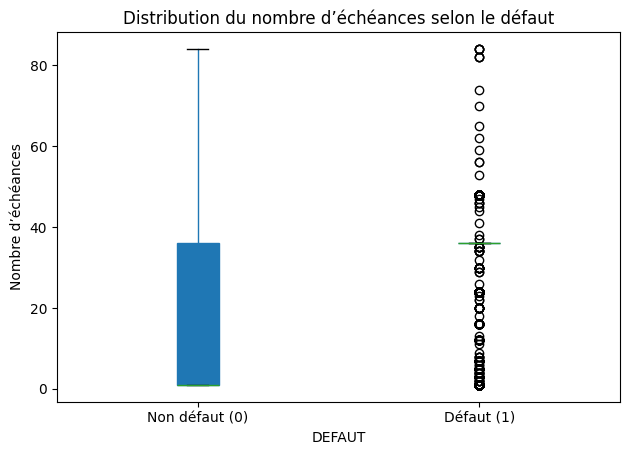

In [25]:
plt.figure(figsize=(8, 5))

data.boxplot(
    column=variable,
    by=target,
    grid=False,
    patch_artist=True
)

plt.title("Distribution du nombre d’échéances selon le défaut")
plt.suptitle('')
plt.xlabel('DEFAUT')
plt.ylabel("Nombre d’échéances")
plt.xticks([1, 2], ['Non défaut (0)', 'Défaut (1)'])

plt.tight_layout()
plt.show()

In [26]:
groupe_0 = data.loc[data[target] == 0, variable]
groupe_1 = data.loc[data[target] == 1, variable]

stat, p_value = mannwhitneyu(
    groupe_0,
    groupe_1,
    alternative='two-sided'
)

print("Statistique Mann-Whitney U :", round(stat, 4))
print("p-value :", round(p_value, 4))

if p_value < 0.05:
    print("Conclusion : Il existe une différence significative du nombre d’échéances entre les clients en défaut et les clients non en défaut.")
else:
    print("Conclusion : Il n'existe pas de différence significative du nombre d’échéances entre les clients en défaut et les clients non en défaut.")

Statistique Mann-Whitney U : 33692684.0
p-value : 0.0
Conclusion : Il existe une différence significative du nombre d’échéances entre les clients en défaut et les clients non en défaut.


In [27]:
n0 = len(groupe_0)
n1 = len(groupe_1)

rank_biserial = (2 * stat) / (n0 * n1) - 1

print("Rank-biserial correlation :", round(rank_biserial, 4))

abs_effect = abs(rank_biserial)

if abs_effect < 0.1:
    interpretation = "très faible"
elif abs_effect < 0.3:
    interpretation = "faible"
elif abs_effect < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La taille de l'effet est {interpretation}.")

Rank-biserial correlation : -0.5909
Interprétation : La taille de l'effet est forte.


### DEFAUT x VALEURGARANT

### DEFAUT x AGE

In [28]:
variable = 'AGE'
target = 'DEFAUT'

# Convertir AGE en numérique
df[variable] = pd.to_numeric(df[variable], errors='coerce')

# Garder seulement les lignes utiles
data = df[[variable, target]].dropna()

# Garder seulement DEFAUT = 0 et DEFAUT = 1
data = data[data[target].isin([0, 1])]

In [29]:
summary_age = data.groupby(target)[variable].agg(
    Effectif='count',
    Moyenne='mean',
    Médiane='median',
    Minimum='min',
    Maximum='max',
    Ecart_type='std'
).round(2)

summary_age

,Effectif,Moyenne,Médiane,Minimum,Maximum,Ecart_type
DEFAUT,,,,,,
0,12431,53.91,53.0,23,90,11.75
1,13249,49.32,49.0,22,90,12.38


<Figure size 800x500 with 0 Axes>

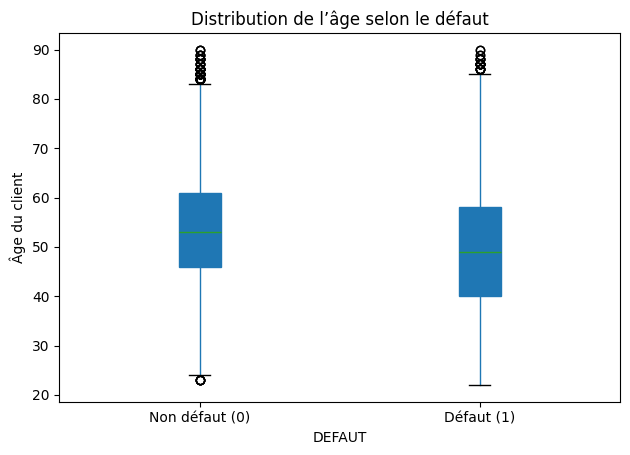

In [30]:
plt.figure(figsize=(8, 5))

data.boxplot(
    column=variable,
    by=target,
    grid=False,
    patch_artist=True
)

plt.title("Distribution de l’âge selon le défaut")
plt.suptitle('')
plt.xlabel('DEFAUT')
plt.ylabel("Âge du client")
plt.xticks([1, 2], ['Non défaut (0)', 'Défaut (1)'])

plt.tight_layout()
plt.show()

In [32]:
groupe_0 = data.loc[data[target] == 0, variable]
groupe_1 = data.loc[data[target] == 1, variable]

stat, p_value = mannwhitneyu(
    groupe_0,
    groupe_1,
    alternative='two-sided'
)

print("Statistique Mann-Whitney U :", round(stat, 4))
print("p-value :", p_value)

if p_value < 0.05:
    print("Conclusion : Il existe une différence significative de l’âge entre les clients en défaut et les clients non en défaut.")
else:
    print("Conclusion : Il n'existe pas de différence significative de l’âge entre les clients en défaut et les clients non en défaut.")

Statistique Mann-Whitney U : 99051574.0
p-value : 2.997365277028044e-174
Conclusion : Il existe une différence significative de l’âge entre les clients en défaut et les clients non en défaut.
